# Task 3: NMS Threshold Design

This notebook supports Task 3 of the TechTrack case analysis. It uses the best-performing model from Task 1, Model 2, and evaluates different Non-Maximum Suppression (NMS) IoU thresholds on the 5,000-image rare-aware density-stratified sample selected in Task 2.

The purpose of this notebook is to decide which NMS threshold should be used in the TechTrack detection pipeline. The decision is based not only on aggregate mAP@0.5, but also on post-NMS prediction count, duplicate-like detections, per-class AP stability, and crowded-scene behavior.

## Methodology

The design question for this task is:

**Which NMS IoU threshold gives the best deployment trade-off for the TechTrack detector?**

The experiment holds the following conditions constant:

- Model: `model2`, selected in Task 1.
- Dataset: `rare_aware_density_stratified_5000`, selected in Task 2.
- Score threshold: `0.5`.
- Evaluation IoU threshold: `0.5`.
- Evaluation method: the implemented `metrics.py` pipeline using 11-point interpolated mAP.

The experiment varies only the NMS IoU threshold:

`0.2, 0.3, 0.4, 0.5, 0.55, 0.6, 0.7`

This isolates the NMS parameter from other system settings. Model inference is run once to save pre-NMS detections, and the existing assignment `NMS` module is then applied repeatedly at different IoU thresholds.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        expected = candidate / "analysis" / "outputs" / "task3_nts_nms_threshold_summary_selected_sample.csv"
        if expected.exists():
            return candidate
    raise FileNotFoundError("Could not locate repo root containing Task 3 output CSVs.")

ROOT = find_repo_root(Path.cwd())
OUT = ROOT / "analysis" / "outputs"
FIG = ROOT / "analysis" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

summary = pd.read_csv(OUT / "task3_nts_nms_threshold_summary_selected_sample.csv")
per_class = pd.read_csv(OUT / "task3_nts_per_class_ap_by_nms_threshold_selected_sample.csv")
duplicates = pd.read_csv(OUT / "task3_nts_duplicate_summary_by_nms_threshold_selected_sample.csv")
subset_summary = pd.read_csv(OUT / "task3_nts_subset_summary_by_nms_threshold_selected_sample.csv")

summary = summary.sort_values("nms_threshold").reset_index(drop=True)
duplicates = duplicates.sort_values("nms_threshold").reset_index(drop=True)
subset_summary = subset_summary.sort_values(["subset_name", "nms_threshold"]).reset_index(drop=True)

RECOMMENDED_NMS = 0.5

ROOT, OUT, FIG

(PosixPath('/home/armin/code/techtrack-arminrahbar'),
 PosixPath('/home/armin/code/techtrack-arminrahbar/analysis/outputs'),
 PosixPath('/home/armin/code/techtrack-arminrahbar/analysis/figures'))

## Table 1: NMS Threshold Sweep Summary

This table summarizes the main threshold sweep. It combines mAP@0.5, prediction count, and duplicate-like prediction diagnostics for each NMS IoU threshold.

In [2]:
sweep_table = summary.merge(
    duplicates,
    on=["nms_threshold", "total_predictions_after_nms"],
    how="left",
)

sweep_display = sweep_table.copy()
sweep_display = sweep_display.rename(columns={
    "nms_threshold": "NMS IoU Threshold",
    "mAP@0.5_11_point": "mAP@0.5",
    "total_ground_truth": "Ground Truth Objects",
    "total_predictions_after_nms": "Predictions After NMS",
    "evaluation_rows": "Evaluation Rows",
    "duplicate_like_pairs_iou_gt_0_5": "Duplicate-Like Pairs: IoU > 0.5",
    "images_with_duplicate_like_pairs": "Images with Duplicate-Like Pairs",
    "mean_duplicate_like_pairs_per_image": "Mean Duplicate-Like Pairs/Image",
})

sweep_display["mAP@0.5"] = sweep_display["mAP@0.5"].round(6)
sweep_display["Mean Duplicate-Like Pairs/Image"] = sweep_display["Mean Duplicate-Like Pairs/Image"].round(6)

sweep_display[[
    "NMS IoU Threshold",
    "mAP@0.5",
    "Predictions After NMS",
    "Duplicate-Like Pairs: IoU > 0.5",
    "Images with Duplicate-Like Pairs",
    "Mean Duplicate-Like Pairs/Image",
]]

,NMS IoU Threshold,mAP@0.5,Predictions After NMS,Duplicate-Like Pairs: IoU > 0.5,Images with Duplicate-Like Pairs,Mean Duplicate-Like Pairs/Image
0,0.20,0.533896,10512,0,0,0.000000
1,0.30,0.542553,10791,0,0,0.000000
2,0.40,0.549908,10984,0,0,0.000000
3,0.50,0.550528,11157,0,0,0.000000
4,0.55,0.550528,11277,86,78,0.021198
5,0.60,0.551376,11433,211,188,0.052009
6,0.70,0.541584,12082,856,623,0.210993


**Interpretation.** mAP rises as the NMS threshold is relaxed from 0.2 to 0.6, but the gain becomes very small after 0.5. At the same time, duplicate-like detections begin appearing above 0.5. Thresholds from 0.2 through 0.5 produce zero same-class duplicate-like prediction pairs with IoU greater than 0.5. At 0.55, duplicate-like pairs appear without any meaningful mAP gain. At 0.6, mAP is numerically highest, but the gain over 0.5 is only about 0.00085 while duplicate-like prediction pairs increase to 211. At 0.7, mAP drops and duplicate-like predictions increase sharply.

## Figure 1: mAP@0.5 Across NMS IoU Thresholds

This figure shows the aggregate mAP@0.5 response to different NMS IoU thresholds.

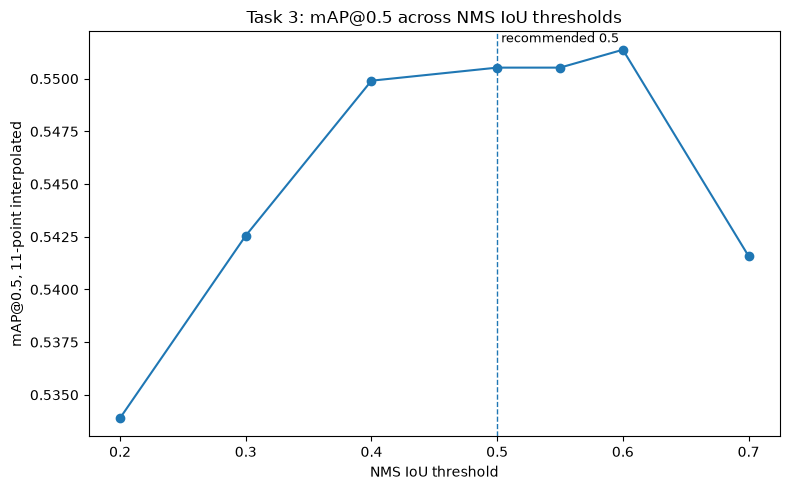

PosixPath('/home/armin/code/techtrack-arminrahbar/analysis/figures/task3_nts_map_by_nms_threshold_selected_sample.png')

In [3]:
plt.figure(figsize=(8, 5))
plt.plot(summary["nms_threshold"], summary["mAP@0.5_11_point"], marker="o")
plt.axvline(RECOMMENDED_NMS, linestyle="--", linewidth=1)
plt.text(RECOMMENDED_NMS, plt.ylim()[1], " recommended 0.5", va="top", ha="left", fontsize=9)
plt.xlabel("NMS IoU threshold")
plt.ylabel("mAP@0.5, 11-point interpolated")
plt.title("Task 3: mAP@0.5 across NMS IoU thresholds")
plt.tight_layout()

figure1_path = FIG / "task3_nts_map_by_nms_threshold_selected_sample.png"
plt.savefig(figure1_path, dpi=200, bbox_inches="tight")
plt.show()

figure1_path

**Interpretation.** The mAP curve shows that very aggressive NMS thresholds, especially 0.2 and 0.3, suppress too much and produce lower mAP. The curve flattens near 0.5, 0.55, and 0.6. Although 0.6 is the numerical peak, the improvement over 0.5 is too small to justify the duplicate-like detections introduced at looser thresholds.

## Figure 2: Post-NMS Prediction Count Across Thresholds

This figure shows how many detections remain after the NMS module at each threshold.

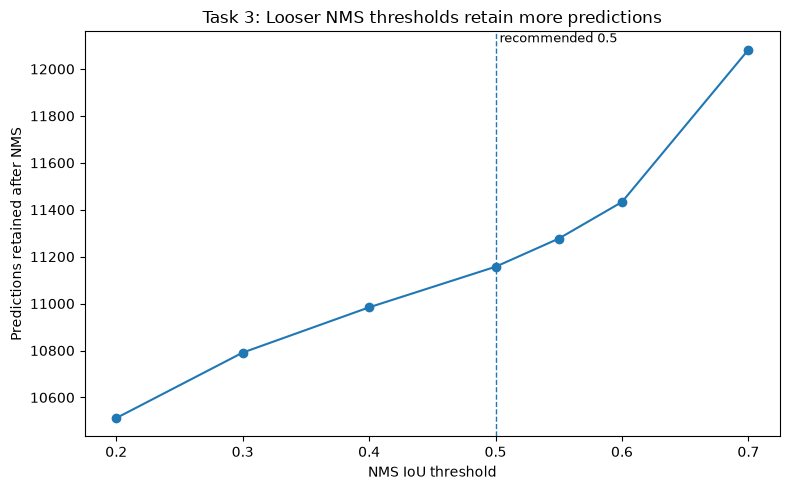

PosixPath('/home/armin/code/techtrack-arminrahbar/analysis/figures/task3_nts_prediction_count_by_nms_threshold_selected_sample.png')

In [4]:
plt.figure(figsize=(8, 5))
plt.plot(summary["nms_threshold"], summary["total_predictions_after_nms"], marker="o")
plt.axvline(RECOMMENDED_NMS, linestyle="--", linewidth=1)
plt.text(RECOMMENDED_NMS, plt.ylim()[1], " recommended 0.5", va="top", ha="left", fontsize=9)
plt.xlabel("NMS IoU threshold")
plt.ylabel("Predictions retained after NMS")
plt.title("Task 3: Looser NMS thresholds retain more predictions")
plt.tight_layout()

figure2_path = FIG / "task3_nts_prediction_count_by_nms_threshold_selected_sample.png"
plt.savefig(figure2_path, dpi=200, bbox_inches="tight")
plt.show()

figure2_path

**Interpretation.** Prediction count increases as the NMS threshold becomes looser. This is expected because higher thresholds allow more overlapping boxes to survive suppression. A higher prediction count is not automatically bad, but it can increase downstream review burden and duplicate detections if the retained boxes are redundant rather than useful true positives.

## Figure 3: Duplicate-Like Prediction Pairs Across Thresholds

This figure counts same-class post-NMS prediction pairs with IoU greater than 0.5. This is a duplicate-like detection proxy, not an AP metric.

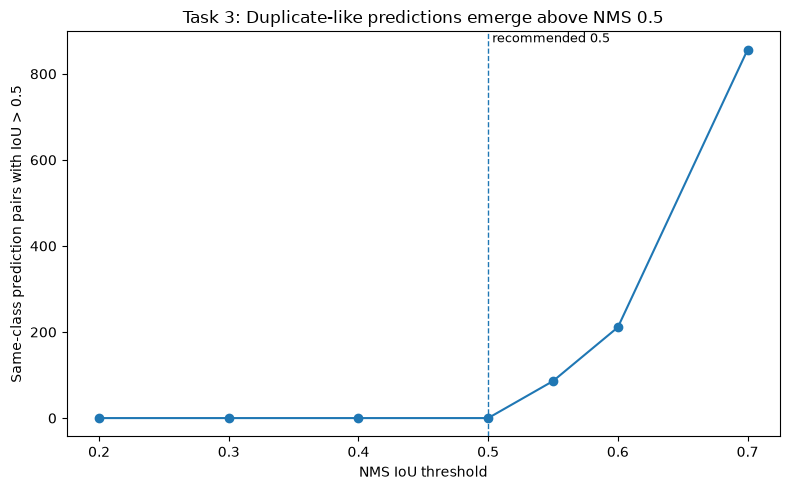

PosixPath('/home/armin/code/techtrack-arminrahbar/analysis/figures/task3_nts_duplicate_like_pairs_by_nms_threshold_selected_sample.png')

In [5]:
plt.figure(figsize=(8, 5))
plt.plot(duplicates["nms_threshold"], duplicates["duplicate_like_pairs_iou_gt_0_5"], marker="o")
plt.axvline(RECOMMENDED_NMS, linestyle="--", linewidth=1)
plt.text(RECOMMENDED_NMS, plt.ylim()[1], " recommended 0.5", va="top", ha="left", fontsize=9)
plt.xlabel("NMS IoU threshold")
plt.ylabel("Same-class prediction pairs with IoU > 0.5")
plt.title("Task 3: Duplicate-like predictions emerge above NMS 0.5")
plt.tight_layout()

figure3_path = FIG / "task3_nts_duplicate_like_pairs_by_nms_threshold_selected_sample.png"
plt.savefig(figure3_path, dpi=200, bbox_inches="tight")
plt.show()

figure3_path

**Interpretation.** This is the strongest evidence against choosing a threshold above 0.5. At 0.55, duplicate-like pairs appear even though mAP does not improve over 0.5. At 0.6, duplicate-like pairs increase to 211 for only a tiny aggregate mAP gain. At 0.7, duplicate-like pairs rise sharply and mAP drops. This supports choosing 0.5 as the cleaner operating point.

## Table 2: Focused Threshold Decision Table

This table compares the main candidate thresholds around the decision boundary. Threshold 0.5 is used as the reference point.

In [6]:
decision_table = sweep_table[sweep_table["nms_threshold"].isin([0.5, 0.55, 0.6, 0.7])].copy()

base_map = float(decision_table.loc[decision_table["nms_threshold"] == 0.5, "mAP@0.5_11_point"].iloc[0])
base_preds = int(decision_table.loc[decision_table["nms_threshold"] == 0.5, "total_predictions_after_nms"].iloc[0])

decision_table["mAP_change_vs_0_5"] = decision_table["mAP@0.5_11_point"] - base_map
decision_table["prediction_change_vs_0_5"] = decision_table["total_predictions_after_nms"] - base_preds

decision_display = decision_table.rename(columns={
    "nms_threshold": "NMS IoU Threshold",
    "mAP@0.5_11_point": "mAP@0.5",
    "mAP_change_vs_0_5": "mAP Change vs 0.5",
    "total_predictions_after_nms": "Predictions After NMS",
    "prediction_change_vs_0_5": "Prediction Change vs 0.5",
    "duplicate_like_pairs_iou_gt_0_5": "Duplicate-Like Pairs: IoU > 0.5",
    "images_with_duplicate_like_pairs": "Images with Duplicate-Like Pairs",
})

for col in ["mAP@0.5", "mAP Change vs 0.5"]:
    decision_display[col] = decision_display[col].round(6)

decision_display[[
    "NMS IoU Threshold",
    "mAP@0.5",
    "mAP Change vs 0.5",
    "Predictions After NMS",
    "Prediction Change vs 0.5",
    "Duplicate-Like Pairs: IoU > 0.5",
    "Images with Duplicate-Like Pairs",
]]

,NMS IoU Threshold,mAP@0.5,mAP Change vs 0.5,Predictions After NMS,Prediction Change vs 0.5,Duplicate-Like Pairs: IoU > 0.5,Images with Duplicate-Like Pairs
3,0.50,0.550528,0.000000,11157,0,0,0
4,0.55,0.550528,-0.000000,11277,120,86,78
5,0.60,0.551376,0.000848,11433,276,211,188
6,0.70,0.541584,-0.008944,12082,925,856,623


**Interpretation.** Threshold 0.55 gives effectively the same mAP as 0.5, but retains 120 additional predictions and introduces 86 duplicate-like pairs. Threshold 0.6 gives the highest mAP, but the gain over 0.5 is only 0.00085 while adding 276 predictions and 211 duplicate-like pairs. Threshold 0.7 is clearly worse because it reduces mAP and greatly increases duplicate-like predictions. Therefore, 0.5 is the best threshold when accuracy and clean post-processing are considered together.

## Table 3: Per-Class Sensitivity Near the Decision Boundary

This table compares AP at thresholds 0.5, 0.55, and 0.6. It checks whether looser thresholds improve performance broadly or only through isolated class effects.

In [7]:
wide = per_class.pivot(
    index=["class_id", "class_name", "ground_truth_count"],
    columns="nms_threshold",
    values="ap_11_point"
).reset_index()

wide["diff_0_55_minus_0_5"] = wide[0.55] - wide[0.5]
wide["diff_0_6_minus_0_5"] = wide[0.6] - wide[0.5]
wide["abs_diff_0_6_minus_0_5"] = wide["diff_0_6_minus_0_5"].abs()

per_class_focus = wide.sort_values("abs_diff_0_6_minus_0_5", ascending=False).head(10).copy()

per_class_display = per_class_focus.rename(columns={
    "class_name": "Class",
    "ground_truth_count": "Ground Truth Count",
    0.5: "AP at NMS 0.5",
    0.55: "AP at NMS 0.55",
    0.6: "AP at NMS 0.6",
    "diff_0_55_minus_0_5": "AP Diff: 0.55 - 0.5",
    "diff_0_6_minus_0_5": "AP Diff: 0.6 - 0.5",
})

for col in [
    "AP at NMS 0.5",
    "AP at NMS 0.55",
    "AP at NMS 0.6",
    "AP Diff: 0.55 - 0.5",
    "AP Diff: 0.6 - 0.5",
]:
    per_class_display[col] = per_class_display[col].round(6)

per_class_display[[
    "Class",
    "Ground Truth Count",
    "AP at NMS 0.5",
    "AP at NMS 0.55",
    "AP at NMS 0.6",
    "AP Diff: 0.55 - 0.5",
    "AP Diff: 0.6 - 0.5",
]]

nms_threshold,Class,Ground Truth Count,AP at NMS 0.5,AP at NMS 0.55,AP at NMS 0.6,AP Diff: 0.55 - 0.5,AP Diff: 0.6 - 0.5
13,safety vest,659,0.530797,0.547159,0.602563,0.016361,0.071766
8,ladder,153,0.339936,0.340038,0.329099,0.000102,-0.010837
17,truck,415,0.760691,0.759145,0.750337,-0.001546,-0.010354
1,car,737,0.632194,0.629393,0.624872,-0.002801,-0.007323
18,van,394,0.789553,0.787677,0.782596,-0.001876,-0.006958
15,traffic cone,240,0.728098,0.723381,0.722664,-0.004718,-0.005434
10,person,3272,0.586777,0.587064,0.591420,0.000287,0.004643
19,wood pallet,4816,0.515366,0.513192,0.511227,-0.002173,-0.004138
4,forklift,583,0.715011,0.713433,0.710882,-0.001578,-0.004129
5,freight container,177,0.184114,0.184104,0.181218,-0.000009,-0.002896


In [8]:
class_sensitivity_summary = pd.DataFrame([
    {
        "comparison": "0.55 vs 0.5",
        "classes_improved": int((wide["diff_0_55_minus_0_5"] > 0).sum()),
        "classes_unchanged": int((wide["diff_0_55_minus_0_5"] == 0).sum()),
        "classes_worsened": int((wide["diff_0_55_minus_0_5"] < 0).sum()),
    },
    {
        "comparison": "0.6 vs 0.5",
        "classes_improved": int((wide["diff_0_6_minus_0_5"] > 0).sum()),
        "classes_unchanged": int((wide["diff_0_6_minus_0_5"] == 0).sum()),
        "classes_worsened": int((wide["diff_0_6_minus_0_5"] < 0).sum()),
    },
])

class_sensitivity_summary

,comparison,classes_improved,classes_unchanged,classes_worsened
0,0.55 vs 0.5,4,0,16
1,0.6 vs 0.5,2,0,18


**Interpretation.** The class-level comparison shows that looser thresholds do not improve performance broadly. Threshold 0.55 improves only 4 classes and worsens 16. Threshold 0.6 improves only 2 classes and worsens 18. The aggregate mAP peak at 0.6 is mainly driven by safety vest AP, not by broad class-level improvement. This supports choosing 0.5 as the more stable threshold.

## Crowded-Image Subset Check

Because NMS matters most when objects overlap, I also evaluated the threshold sweep on a subset of crowded images. The crowded subset contains selected-sample images with at least one pair of ground-truth boxes whose IoU is greater than 0.1.

This subset check does not change the metric definition. It only tests whether the recommended threshold remains reasonable on images where suppression risk is higher.

In [9]:
subset_focus = subset_summary[
    subset_summary["nms_threshold"].isin([0.5, 0.55, 0.6, 0.7])
].copy()

subset_display = subset_focus.rename(columns={
    "subset_name": "Subset",
    "image_count": "Images",
    "ground_truth_count": "Ground Truth Objects",
    "nms_threshold": "NMS IoU Threshold",
    "mAP@0.5_11_point": "mAP@0.5",
    "total_predictions_after_nms": "Predictions After NMS",
    "duplicate_like_pairs_iou_gt_0_5": "Duplicate-Like Pairs: IoU > 0.5",
    "images_with_duplicate_like_pairs": "Images with Duplicate-Like Pairs",
})

subset_display["Subset"] = subset_display["Subset"].replace({
    "all_selected": "All selected images",
    "crowded_any_overlap": "Crowded images",
})

subset_display["mAP@0.5"] = subset_display["mAP@0.5"].round(6)

subset_display[[
    "Subset",
    "Images",
    "Ground Truth Objects",
    "NMS IoU Threshold",
    "mAP@0.5",
    "Predictions After NMS",
    "Duplicate-Like Pairs: IoU > 0.5",
    "Images with Duplicate-Like Pairs",
]]

,Subset,Images,Ground Truth Objects,NMS IoU Threshold,mAP@0.5,Predictions After NMS,Duplicate-Like Pairs: IoU > 0.5,Images with Duplicate-Like Pairs
3,All selected images,5000,19196,0.50,0.550528,11157,0,0
4,All selected images,5000,19196,0.55,0.550528,11277,86,78
5,All selected images,5000,19196,0.60,0.551376,11433,211,188
6,All selected images,5000,19196,0.70,0.541584,12082,856,623
10,Crowded images,1021,11411,0.50,0.343477,5953,0,0
11,Crowded images,1021,11411,0.55,0.343512,6037,50,43
12,Crowded images,1021,11411,0.60,0.346863,6130,114,92
13,Crowded images,1021,11411,0.70,0.346436,6406,341,232


## Figure 4: mAP@0.5 by Threshold for All and Crowded Images

This figure compares the full selected sample with the crowded-image subset.

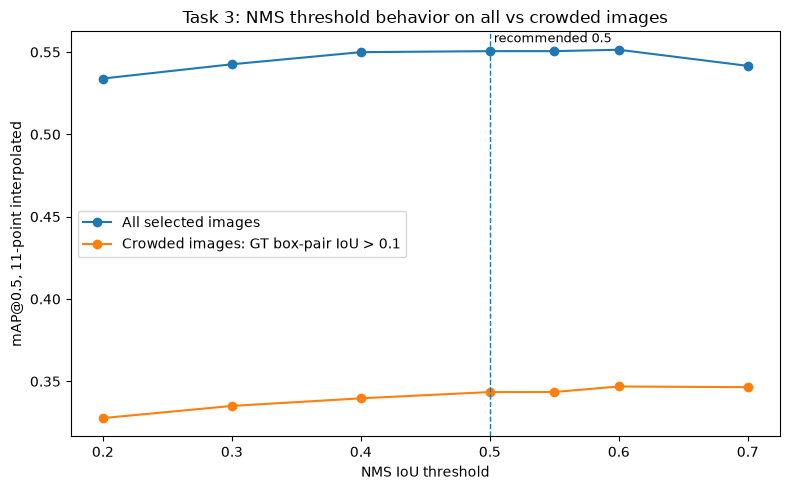

PosixPath('/home/armin/code/techtrack-arminrahbar/analysis/figures/task3_nts_map_by_nms_threshold_and_subset_selected_sample.png')

In [10]:
label_map = {
    "all_selected": "All selected images",
    "crowded_any_overlap": "Crowded images: GT box-pair IoU > 0.1",
}

plt.figure(figsize=(8, 5))
for subset_name, group in subset_summary.groupby("subset_name"):
    group = group.sort_values("nms_threshold")
    plt.plot(
        group["nms_threshold"],
        group["mAP@0.5_11_point"],
        marker="o",
        label=label_map.get(subset_name, subset_name),
    )

plt.axvline(RECOMMENDED_NMS, linestyle="--", linewidth=1)
plt.text(RECOMMENDED_NMS, plt.ylim()[1], " recommended 0.5", va="top", ha="left", fontsize=9)
plt.xlabel("NMS IoU threshold")
plt.ylabel("mAP@0.5, 11-point interpolated")
plt.title("Task 3: NMS threshold behavior on all vs crowded images")
plt.legend()
plt.tight_layout()

figure4_path = FIG / "task3_nts_map_by_nms_threshold_and_subset_selected_sample.png"
plt.savefig(figure4_path, dpi=200, bbox_inches="tight")
plt.show()

figure4_path

**Interpretation.** The crowded-image subset has lower mAP than the full selected sample, which is expected because overlapping objects are harder to detect cleanly. Looser thresholds slightly improve crowded-image mAP, but they also introduce duplicate-like predictions. At 0.55, crowded-image mAP is essentially unchanged compared with 0.5, while duplicate-like pairs appear. At 0.6, crowded-image mAP improves slightly, but duplicate-like pairs increase. This subset check supports the same deployment recommendation: 0.5 is the cleaner threshold.

## Task 3 Conclusion

The recommended NMS IoU threshold is **0.5**.

Although threshold 0.6 produces the highest aggregate mAP@0.5, the gain over 0.5 is only about 0.00085. That small gain is not a strong deployment reason to accept the additional duplicate-like detections introduced by 0.6. Threshold 0.55 also fails to justify moving above 0.5 because it produces effectively the same mAP as 0.5 while creating duplicate-like prediction pairs.

The recommended threshold, 0.5, gives the best engineering trade-off under the tested conditions: it provides near-maximum mAP, keeps post-NMS output cleaner, avoids duplicate-like same-class prediction pairs, and remains defensible on crowded images where NMS suppression risk is highest.

## Appendix A: Full Task 3 Pipeline Code

This appendix records the script used to generate the Task 3 CSV outputs and figures. The notebook above loads the verified outputs from this script and presents the tables and figures used in the case analysis.

### `analysis/task3_nms_threshold_sweep.py`

```python
from pathlib import Path
import sys
import argparse
import json
import time

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path(__file__).resolve().parents[1]
sys.path.insert(0, str(ROOT))

from techtrack.modules.inference.model import Detector
from techtrack.modules.inference.nms import NMS
from techtrack.modules.utils.metrics import (
    match_detections,
    calculate_precision_recall_curve,
    calculate_map_x_point_interpolated,
    calculate_iou,
)

OUT = ROOT / "analysis" / "outputs"
FIG = ROOT / "analysis" / "figures"
OUT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

PREFIX = "task3_nts"

SAMPLE_INDEX = OUT / "task2_selected_sample_index.csv"
OVERLAP_PROFILE = OUT / "task2_image_overlap_profile.csv"

CLASS_FILE = ROOT / "techtrack" / "storage" / "yolo_model_2" / "logistics.names"

MODEL2 = {
    "weights": ROOT / "techtrack/storage/yolo_model_2/yolov4-tiny-logistics_size_416_2.weights",
    "cfg": ROOT / "techtrack/storage/yolo_model_2/yolov4-tiny-logistics_size_416_2.cfg",
    "names": ROOT / "techtrack/storage/yolo_model_2/logistics.names",
}

MODEL_NAME = "model2"
DATASET_NAME = "rare_aware_density_stratified_5000"

SCORE_THRESHOLD = 0.5
MAP_IOU_THRESHOLD = 0.5
EVAL_TYPE = "combined"

NMS_THRESHOLDS = [0.2, 0.3, 0.4, 0.5, 0.55, 0.6, 0.7]

RAW_COLUMNS = [
    "model",
    "image_file",
    "image_path",
    "bbox_x",
    "bbox_y",
    "bbox_w",
    "bbox_h",
    "class_id",
    "class_name",
    "object_score",
    "predicted_class_score",
    "combined_confidence",
    "class_scores_json",
]

PRED_COLUMNS = RAW_COLUMNS + ["nms_threshold"]

GT_COLUMNS = [
    "image_file",
    "image_path",
    "class_id",
    "class_name",
    "bbox_x",
    "bbox_y",
    "bbox_w",
    "bbox_h",
]


def load_classes():
    return [line.strip() for line in CLASS_FILE.read_text().splitlines() if line.strip()]


def yolo_label_to_xywh(label_path: Path, image_w: int, image_h: int, classes):
    rows = []
    text = label_path.read_text().strip()

    if not text:
        return rows

    for line in text.splitlines():
        parts = line.strip().split()
        if len(parts) < 5:
            continue

        class_id = int(float(parts[0]))

        if class_id < 0 or class_id >= len(classes):
            continue

        x_center = float(parts[1]) * image_w
        y_center = float(parts[2]) * image_h
        box_w = float(parts[3]) * image_w
        box_h = float(parts[4]) * image_h

        x = x_center - box_w / 2
        y = y_center - box_h / 2

        rows.append({
            "class_id": class_id,
            "class_name": classes[class_id],
            "bbox_x": x,
            "bbox_y": y,
            "bbox_w": box_w,
            "bbox_h": box_h,
        })

    return rows


def build_ground_truth(idx, classes, suffix, force=False):
    gt_path = OUT / f"{PREFIX}_ground_truth{suffix}.csv"

    if gt_path.exists() and not force:
        print(f"[SKIP] Ground truth already exists: {gt_path}")
        return pd.read_csv(gt_path)

    print("=" * 100)
    print("Building Task 3 ground-truth table")
    print("=" * 100)

    rows = []

    for row_num, (_, row) in enumerate(idx.iterrows(), start=1):
        image_path = ROOT / row["image_path"]
        label_path = ROOT / row["label_path"]

        frame = cv2.imread(str(image_path))
        if frame is None:
            print(f"[WARN] Could not read image for GT conversion: {image_path}")
            continue

        image_h, image_w = frame.shape[:2]

        for gt in yolo_label_to_xywh(label_path, image_w, image_h, classes):
            rows.append({
                "image_file": row["image_file"],
                "image_path": row["image_path"],
                "class_id": gt["class_id"],
                "class_name": gt["class_name"],
                "bbox_x": gt["bbox_x"],
                "bbox_y": gt["bbox_y"],
                "bbox_w": gt["bbox_w"],
                "bbox_h": gt["bbox_h"],
            })

        if row_num % 1000 == 0:
            print(f"[GT] processed {row_num}/{len(idx)} images")

    gt_df = pd.DataFrame(rows, columns=GT_COLUMNS)
    gt_df.to_csv(gt_path, index=False)

    print(f"[WRITE] {gt_path} rows={len(gt_df)}")
    return gt_df


def run_raw_inference_model2(idx, classes, suffix, force=False):
    raw_path = OUT / f"{PREFIX}_{MODEL_NAME}_raw_predictions{suffix}.csv"

    if raw_path.exists() and not force:
        print(f"[SKIP] Raw predictions already exist: {raw_path}")
        return pd.read_csv(raw_path)

    print("=" * 100)
    print("Running Model 2 inference once and saving pre-NMS detections")
    print("=" * 100)

    detector = Detector(
        str(MODEL2["weights"]),
        str(MODEL2["cfg"]),
        str(MODEL2["names"]),
        score_threshold=SCORE_THRESHOLD,
    )

    rows = []
    start = time.time()

    for row_num, (_, row) in enumerate(idx.iterrows(), start=1):
        image_path = ROOT / row["image_path"]
        frame = cv2.imread(str(image_path))

        if frame is None:
            print(f"[WARN] Could not read image: {image_path}")
            continue

        outputs = detector.predict(frame)
        bboxes, class_ids, scores, class_scores = detector.post_process(outputs)

        for det_idx, bbox in enumerate(bboxes):
            class_id = int(class_ids[det_idx])
            object_score = float(scores[det_idx])

            score_vector = np.asarray(class_scores[det_idx], dtype=float).ravel()
            score_vector = [float(v) for v in score_vector]

            if 0 <= class_id < len(score_vector):
                predicted_class_score = float(score_vector[class_id])
            else:
                predicted_class_score = 0.0

            combined_confidence = object_score * predicted_class_score

            rows.append({
                "model": MODEL_NAME,
                "image_file": row["image_file"],
                "image_path": row["image_path"],
                "bbox_x": float(bbox[0]),
                "bbox_y": float(bbox[1]),
                "bbox_w": float(bbox[2]),
                "bbox_h": float(bbox[3]),
                "class_id": class_id,
                "class_name": classes[class_id] if 0 <= class_id < len(classes) else "unknown",
                "object_score": object_score,
                "predicted_class_score": predicted_class_score,
                "combined_confidence": combined_confidence,
                "class_scores_json": json.dumps(score_vector),
            })

        if row_num % 250 == 0:
            elapsed = time.time() - start
            print(
                f"[RAW] processed {row_num}/{len(idx)} images | "
                f"raw detections={len(rows)} | elapsed={elapsed:.1f}s"
            )

    raw_df = pd.DataFrame(rows, columns=RAW_COLUMNS)
    raw_df.to_csv(raw_path, index=False)

    elapsed = time.time() - start
    print(f"[WRITE] {raw_path} rows={len(raw_df)}")
    print(f"[DONE] raw inference elapsed seconds: {elapsed:.2f}")

    return raw_df


def apply_nms_threshold(raw_df, idx, classes, nms_threshold, suffix, force=False):
    threshold_tag = str(nms_threshold).replace(".", "_")
    pred_path = OUT / f"{PREFIX}_{MODEL_NAME}_predictions_nms_{threshold_tag}{suffix}.csv"

    if pred_path.exists() and not force:
        print(f"[SKIP] NMS predictions already exist: {pred_path}")
        return pd.read_csv(pred_path)

    print("=" * 100)
    print(f"Applying assignment NMS module with threshold = {nms_threshold}")
    print("=" * 100)

    nms = NMS(
        score_threshold=SCORE_THRESHOLD,
        nms_iou_threshold=nms_threshold,
    )

    raw_groups = {k: v for k, v in raw_df.groupby("image_file")} if len(raw_df) else {}
    rows = []

    for row_num, (_, row) in enumerate(idx.iterrows(), start=1):
        image_file = row["image_file"]
        group = raw_groups.get(image_file)

        if group is None or len(group) == 0:
            continue

        bboxes = group[["bbox_x", "bbox_y", "bbox_w", "bbox_h"]].astype(float).values.tolist()
        class_ids = group["class_id"].astype(int).tolist()
        scores = group["object_score"].astype(float).tolist()
        class_scores = [
            json.loads(value)
            for value in group["class_scores_json"].tolist()
        ]

        filtered_boxes, filtered_classes, filtered_scores, filtered_class_scores = nms.filter(
            bboxes,
            class_ids,
            scores,
            class_scores,
        )

        for det_idx, bbox in enumerate(filtered_boxes):
            class_id = int(filtered_classes[det_idx])
            object_score = float(filtered_scores[det_idx])

            score_vector = np.asarray(filtered_class_scores[det_idx], dtype=float).ravel()
            score_vector = [float(v) for v in score_vector]

            if 0 <= class_id < len(score_vector):
                predicted_class_score = float(score_vector[class_id])
            else:
                predicted_class_score = 0.0

            combined_confidence = object_score * predicted_class_score

            rows.append({
                "model": MODEL_NAME,
                "image_file": row["image_file"],
                "image_path": row["image_path"],
                "bbox_x": float(bbox[0]),
                "bbox_y": float(bbox[1]),
                "bbox_w": float(bbox[2]),
                "bbox_h": float(bbox[3]),
                "class_id": class_id,
                "class_name": classes[class_id] if 0 <= class_id < len(classes) else "unknown",
                "object_score": object_score,
                "predicted_class_score": predicted_class_score,
                "combined_confidence": combined_confidence,
                "class_scores_json": json.dumps(score_vector),
                "nms_threshold": nms_threshold,
            })

        if row_num % 1000 == 0:
            print(f"[NMS {nms_threshold}] processed {row_num}/{len(idx)} images")

    pred_df = pd.DataFrame(rows, columns=PRED_COLUMNS)
    pred_df.to_csv(pred_path, index=False)

    print(f"[WRITE] {pred_path} rows={len(pred_df)}")
    return pred_df


def build_metric_lists(idx, pred_df, gt_df):
    pred_groups = {k: v for k, v in pred_df.groupby("image_file")} if len(pred_df) else {}
    gt_groups = {k: v for k, v in gt_df.groupby("image_file")} if len(gt_df) else {}

    boxes = []
    pred_classes = []
    scores = []
    cls_scores = []

    gt_boxes = []
    gt_classes = []

    for _, row in idx.iterrows():
        image_file = row["image_file"]

        pred_group = pred_groups.get(image_file)
        if pred_group is None:
            boxes.append([])
            pred_classes.append([])
            scores.append([])
            cls_scores.append([])
        else:
            boxes.append(pred_group[["bbox_x", "bbox_y", "bbox_w", "bbox_h"]].values.tolist())
            pred_classes.append(pred_group["class_id"].astype(int).tolist())
            scores.append(pred_group["object_score"].astype(float).tolist())
            cls_scores.append([
                json.loads(value)
                for value in pred_group["class_scores_json"].tolist()
            ])

        gt_group = gt_groups.get(image_file)
        if gt_group is None:
            gt_boxes.append([])
            gt_classes.append([])
        else:
            gt_boxes.append(gt_group[["bbox_x", "bbox_y", "bbox_w", "bbox_h"]].values.tolist())
            gt_classes.append(gt_group["class_id"].astype(int).tolist())

    return boxes, pred_classes, scores, cls_scores, gt_boxes, gt_classes


def evaluate_with_metrics_py(idx, pred_df, gt_df, classes, nms_threshold):
    boxes, pred_classes, scores, cls_scores, gt_boxes, gt_classes = build_metric_lists(
        idx,
        pred_df,
        gt_df,
    )

    y_true, pred_scores = match_detections(
        boxes=boxes,
        classes=pred_classes,
        scores=scores,
        cls_scores=cls_scores,
        gt_boxes=gt_boxes,
        gt_classes=gt_classes,
        map_iou_threshold=MAP_IOU_THRESHOLD,
        eval_type=EVAL_TYPE,
    )

    precision, recall, thresholds = calculate_precision_recall_curve(
        y_true,
        pred_scores,
        num_classes=len(classes),
    )

    precision_recall_points = {
        class_id: list(zip(recall[class_id], precision[class_id]))
        for class_id in range(len(classes))
    }

    map_score = calculate_map_x_point_interpolated(
        precision_recall_points,
        num_classes=len(classes),
        num_interpolated_points=11,
    )

    per_class_rows = []

    for class_id, class_name in enumerate(classes):
        per_class_ap = calculate_map_x_point_interpolated(
            {0: precision_recall_points[class_id]},
            num_classes=1,
            num_interpolated_points=11,
        )

        gt_count = int((gt_df["class_id"] == class_id).sum())
        prediction_count = int((pred_df["class_id"] == class_id).sum()) if len(pred_df) else 0

        per_class_rows.append({
            "model": MODEL_NAME,
            "dataset": DATASET_NAME,
            "nms_threshold": nms_threshold,
            "class_id": class_id,
            "class_name": class_name,
            "ground_truth_count": gt_count,
            "prediction_count": prediction_count,
            "ap_11_point": per_class_ap,
        })

    summary = {
        "model": MODEL_NAME,
        "dataset": DATASET_NAME,
        "nms_threshold": nms_threshold,
        "mAP@0.5_11_point": map_score,
        "total_ground_truth": int(len(gt_df)),
        "total_predictions_after_nms": int(len(pred_df)),
        "evaluation_rows": int(len(y_true)),
        "score_threshold": SCORE_THRESHOLD,
        "map_iou_threshold": MAP_IOU_THRESHOLD,
        "eval_type": EVAL_TYPE,
    }

    return summary, pd.DataFrame(per_class_rows)


def count_duplicate_like_prediction_pairs(pred_df, iou_threshold=0.5):
    """
    Counts same-class post-NMS prediction pairs with IoU greater than iou_threshold.

    This is a duplicate-like detection proxy. It is not AP/mAP.
    """
    if len(pred_df) == 0:
        return {
            "duplicate_like_pairs_iou_gt_0_5": 0,
            "images_with_duplicate_like_pairs": 0,
            "mean_duplicate_like_pairs_per_image": 0.0,
        }

    duplicate_pairs_total = 0
    images_with_duplicates = 0

    for _, image_group in pred_df.groupby("image_file"):
        image_pair_count = 0

        for _, class_group in image_group.groupby("class_id"):
            boxes = class_group[["bbox_x", "bbox_y", "bbox_w", "bbox_h"]].astype(float).values.tolist()

            if len(boxes) < 2:
                continue

            for i in range(len(boxes)):
                for j in range(i + 1, len(boxes)):
                    iou = float(calculate_iou(boxes[i], boxes[j]))
                    iou = min(1.0, max(0.0, iou))

                    if iou > iou_threshold:
                        image_pair_count += 1

        duplicate_pairs_total += image_pair_count

        if image_pair_count > 0:
            images_with_duplicates += 1

    total_images = pred_df["image_file"].nunique()

    return {
        "duplicate_like_pairs_iou_gt_0_5": int(duplicate_pairs_total),
        "images_with_duplicate_like_pairs": int(images_with_duplicates),
        "mean_duplicate_like_pairs_per_image": (
            float(duplicate_pairs_total) / float(total_images)
            if total_images > 0 else 0.0
        ),
    }


def build_subset_indices(idx):
    """
    Builds the two Task 3 evaluation groups:
    - all_selected
    - crowded_any_overlap

    crowded_any_overlap uses Task 2 ground-truth overlap profiling:
    images with at least one ground-truth box pair where IoU > 0.1.
    """
    subsets = {
        "all_selected": idx.copy(),
    }

    if not OVERLAP_PROFILE.exists():
        print(f"[WARN] Missing overlap profile: {OVERLAP_PROFILE}")
        print("[WARN] Only all_selected subset will be evaluated.")
        return subsets

    overlap_df = pd.read_csv(OVERLAP_PROFILE)

    selected_image_files = set(idx["image_file"])
    crowded_files = set(
        overlap_df[
            (overlap_df["image_file"].isin(selected_image_files))
            & (overlap_df["pairs_iou_gt_0_1"] > 0)
        ]["image_file"]
    )

    crowded_idx = idx[idx["image_file"].isin(crowded_files)].copy()

    subsets["crowded_any_overlap"] = crowded_idx

    print()
    print("TASK 3 SUBSETS")
    print(f"all_selected images: {len(subsets['all_selected'])}")
    print(f"crowded_any_overlap images: {len(subsets['crowded_any_overlap'])}")

    return subsets


def evaluate_subset_summary(subset_name, subset_idx, pred_df, gt_df, classes, nms_threshold):
    subset_files = set(subset_idx["image_file"])

    subset_pred = pred_df[pred_df["image_file"].isin(subset_files)].copy()
    subset_gt = gt_df[gt_df["image_file"].isin(subset_files)].copy()

    summary, _ = evaluate_with_metrics_py(
        subset_idx,
        subset_pred,
        subset_gt,
        classes,
        nms_threshold=nms_threshold,
    )

    duplicate_stats = count_duplicate_like_prediction_pairs(
        subset_pred,
        iou_threshold=0.5,
    )

    return {
        "subset_name": subset_name,
        "image_count": int(len(subset_idx)),
        "ground_truth_count": int(len(subset_gt)),
        "nms_threshold": nms_threshold,
        "mAP@0.5_11_point": summary["mAP@0.5_11_point"],
        "total_predictions_after_nms": int(len(subset_pred)),
        "evaluation_rows": summary["evaluation_rows"],
        "duplicate_like_pairs_iou_gt_0_5": duplicate_stats["duplicate_like_pairs_iou_gt_0_5"],
        "images_with_duplicate_like_pairs": duplicate_stats["images_with_duplicate_like_pairs"],
        "mean_duplicate_like_pairs_per_image": duplicate_stats["mean_duplicate_like_pairs_per_image"],
    }


def build_figures(summary_df, duplicate_df, subset_summary_df, suffix):
    plt.figure(figsize=(8, 5))
    plt.plot(summary_df["nms_threshold"], summary_df["mAP@0.5_11_point"], marker="o")
    plt.xlabel("NMS IoU threshold")
    plt.ylabel("mAP@0.5, 11-point interpolated")
    plt.title("Task 3: mAP@0.5 by NMS threshold")
    plt.tight_layout()
    fig1 = FIG / f"{PREFIX}_map_by_nms_threshold{suffix}.png"
    plt.savefig(fig1, dpi=200, bbox_inches="tight")
    plt.close()

    plt.figure(figsize=(8, 5))
    plt.plot(summary_df["nms_threshold"], summary_df["total_predictions_after_nms"], marker="o")
    plt.xlabel("NMS IoU threshold")
    plt.ylabel("Predictions after NMS")
    plt.title("Task 3: Prediction count by NMS threshold")
    plt.tight_layout()
    fig2 = FIG / f"{PREFIX}_prediction_count_by_nms_threshold{suffix}.png"
    plt.savefig(fig2, dpi=200, bbox_inches="tight")
    plt.close()

    plt.figure(figsize=(8, 5))
    plt.plot(
        duplicate_df["nms_threshold"],
        duplicate_df["duplicate_like_pairs_iou_gt_0_5"],
        marker="o",
    )
    plt.xlabel("NMS IoU threshold")
    plt.ylabel("Same-class prediction pairs with IoU > 0.5")
    plt.title("Task 3: Duplicate-like prediction pairs by NMS threshold")
    plt.tight_layout()
    fig3 = FIG / f"{PREFIX}_duplicate_like_pairs_by_nms_threshold{suffix}.png"
    plt.savefig(fig3, dpi=200, bbox_inches="tight")
    plt.close()

    plt.figure(figsize=(8, 5))
    for subset_name, group in subset_summary_df.groupby("subset_name"):
        group = group.sort_values("nms_threshold")
        plt.plot(
            group["nms_threshold"],
            group["mAP@0.5_11_point"],
            marker="o",
            label=subset_name,
        )
    plt.xlabel("NMS IoU threshold")
    plt.ylabel("mAP@0.5, 11-point interpolated")
    plt.title("Task 3: mAP@0.5 by NMS threshold and subset")
    plt.legend()
    plt.tight_layout()
    fig4 = FIG / f"{PREFIX}_map_by_nms_threshold_and_subset{suffix}.png"
    plt.savefig(fig4, dpi=200, bbox_inches="tight")
    plt.close()

    print("[WRITE]", fig1)
    print("[WRITE]", fig2)
    print("[WRITE]", fig3)
    print("[WRITE]", fig4)


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--max-images", type=int, default=None)
    parser.add_argument("--force", action="store_true")
    args = parser.parse_args()

    if not SAMPLE_INDEX.exists():
        raise FileNotFoundError(
            f"Missing selected sample index: {SAMPLE_INDEX}. "
            "Run Task 2 sampling first."
        )

    classes = load_classes()
    idx = pd.read_csv(SAMPLE_INDEX)

    if args.max_images is not None:
        idx = idx.head(args.max_images).copy()
        suffix = f"_first_{args.max_images}"
        print(f"[INFO] Running Task 3 on first {args.max_images} selected sample images.")
    else:
        suffix = "_selected_sample"
        print("[INFO] Running Task 3 on full selected 5,000-image sample.")

    print(f"[INFO] Images selected: {len(idx)}")
    print(f"[INFO] Classes: {len(classes)}")
    print(f"[INFO] Model held constant: {MODEL_NAME}")
    print(f"[INFO] Dataset held constant: {DATASET_NAME}")
    print(f"[INFO] Score threshold held constant: {SCORE_THRESHOLD}")
    print(f"[INFO] Evaluation IoU threshold held constant: {MAP_IOU_THRESHOLD}")
    print(f"[INFO] NMS thresholds tested: {NMS_THRESHOLDS}")
    print(f"[INFO] Output prefix: {PREFIX}_")

    subsets = build_subset_indices(idx)

    gt_df = build_ground_truth(idx, classes, suffix=suffix, force=args.force)
    raw_df = run_raw_inference_model2(idx, classes, suffix=suffix, force=args.force)

    summary_rows = []
    per_class_all = []
    duplicate_rows = []
    subset_rows = []

    for nms_threshold in NMS_THRESHOLDS:
        pred_df = apply_nms_threshold(
            raw_df,
            idx,
            classes,
            nms_threshold=nms_threshold,
            suffix=suffix,
            force=args.force,
        )

        summary, per_class_df = evaluate_with_metrics_py(
            idx,
            pred_df,
            gt_df,
            classes,
            nms_threshold=nms_threshold,
        )

        duplicate_stats = count_duplicate_like_prediction_pairs(
            pred_df,
            iou_threshold=0.5,
        )
        duplicate_stats["nms_threshold"] = nms_threshold
        duplicate_stats["total_predictions_after_nms"] = int(len(pred_df))

        summary_rows.append(summary)
        per_class_all.append(per_class_df)
        duplicate_rows.append(duplicate_stats)

        for subset_name, subset_idx in subsets.items():
            subset_rows.append(
                evaluate_subset_summary(
                    subset_name,
                    subset_idx,
                    pred_df,
                    gt_df,
                    classes,
                    nms_threshold=nms_threshold,
                )
            )

    summary_df = pd.DataFrame(summary_rows)
    per_class_df = pd.concat(per_class_all, axis=0, ignore_index=True)
    duplicate_df = pd.DataFrame(duplicate_rows)
    subset_summary_df = pd.DataFrame(subset_rows)

    summary_path = OUT / f"{PREFIX}_nms_threshold_summary{suffix}.csv"
    per_class_path = OUT / f"{PREFIX}_per_class_ap_by_nms_threshold{suffix}.csv"
    duplicate_path = OUT / f"{PREFIX}_duplicate_summary_by_nms_threshold{suffix}.csv"
    subset_path = OUT / f"{PREFIX}_subset_summary_by_nms_threshold{suffix}.csv"

    summary_df.to_csv(summary_path, index=False)
    per_class_df.to_csv(per_class_path, index=False)
    duplicate_df.to_csv(duplicate_path, index=False)
    subset_summary_df.to_csv(subset_path, index=False)

    print()
    print("TASK 3 NMS THRESHOLD SUMMARY")
    print(summary_df.to_string(index=False))

    print()
    print("TASK 3 DUPLICATE-LIKE PREDICTION SUMMARY")
    print(duplicate_df.to_string(index=False))

    print()
    print("TASK 3 SUBSET SUMMARY")
    print(subset_summary_df.to_string(index=False))

    print()
    print("[WRITE]", summary_path)
    print("[WRITE]", per_class_path)
    print("[WRITE]", duplicate_path)
    print("[WRITE]", subset_path)

    build_figures(summary_df, duplicate_df, subset_summary_df, suffix=suffix)


if __name__ == "__main__":
    main()

```